<a href="https://colab.research.google.com/github/TechJas/Job-Search-Platform-Efficiency/blob/main/job_search_platform_efficacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/job-board-effectiveness-for-college-students")

print("Path to dataset files:", path)

100%|██████████| 1.59M/1.59M [00:00<00:00, 116MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/likithagedipudi/job-board-effectiveness-for-college-students/versions/1


In [ ]:
import os
file1 = os.path.join(path,"job_search_platform_efficacy_100k.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv(file1)

In [ ]:
df.head()

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
99995,STU_099996,Lower-tier,Large,Northeast,STEM,3.61,3,1,1,Handshake,3,15,2,1,1,26.0,78811.0,Mid-Size,8.0,0.0
99996,STU_099997,Lower-tier,Large,West,Business,3.39,0,1,4,Indeed,8,120,0,0,0,NaN,NaN,NaN,NaN,NaN
99997,STU_099998,Lower-tier,Small,Northeast,Business,3.38,4,2,2,Indeed,4,60,2,1,0,NaN,NaN,NaN,NaN,NaN
99998,STU_099999,Mid-tier,Large,Midwest,Business,3.20,2,0,0,LinkedIn,7,39,4,1,0,NaN,NaN,NaN,NaN,NaN
99999,STU_100000,Mid-tier,Small,Midwest,STEM,3.62,2,5,7,Handshake,12,5,1,1,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   University_Rating            100000 non-null  object 
 2   School_Size                  100000 non-null  object 
 3   Region                       100000 non-null  object 
 4   Major_Category               100000 non-null  object 
 5   GPA                          100000 non-null  float64
 6   Prior_Internships            100000 non-null  int64  
 7   Extra_Curricular_Activities  100000 non-null  int64  
 8   Networking_Events_Attended   100000 non-null  int64  
 9   Primary_Search_Platform      100000 non-null  object 
 10  Months_Searching             100000 non-null  int64  
 11  Applications_Submitted       100000 non-null  int64  
 12  First_Round_Interviews       100000 non-null  int64  
 13  

In [ ]:
df.isnull().sum()

,0
Student_ID,0
University_Rating,0
School_Size,0
Region,0
Major_Category,0
GPA,0
Prior_Internships,0
Extra_Curricular_Activities,0
Networking_Events_Attended,0
Primary_Search_Platform,0


In [ ]:
df[df['Time_to_Offer_Days'].isna()]

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN
5,STU_000006,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,STU_099995,Lower-tier,Small,West,Business,3.57,2,3,2,Handshake,2,5,0,0,0,NaN,NaN,NaN,NaN,NaN
99996,STU_099997,Lower-tier,Large,West,Business,3.39,0,1,4,Indeed,8,120,0,0,0,NaN,NaN,NaN,NaN,NaN
99997,STU_099998,Lower-tier,Small,Northeast,Business,3.38,4,2,2,Indeed,4,60,2,1,0,NaN,NaN,NaN,NaN,NaN
99998,STU_099999,Mid-tier,Large,Midwest,Business,3.20,2,0,0,LinkedIn,7,39,4,1,0,NaN,NaN,NaN,NaN,NaN


Time_to_Offer_Days HAS null value as 65771 in rows

so, no .of invalid rows in given columns = 65771

total rows is 100000

so, perecntage of bad rows = 65%

>Same applicable to below columns :
     
     (same no of invalid rows in all columns)
*   Offer_Salary
*   Company_Size_Offered
*   Role_Relevance
*   Accepted_Offer  

There are three decision questions professionals ask:

# **Question 1**

Is the missing data small or large?

**Rule of thumb:**

Missing %	  ----    Action :

< 5%	------ Usually safe to drop

5–20% ------	Investigate carefully

> more than 20%	---- Avoid dropping

Your case:

65% is large

So dropping is not safe.

# Question 2

Is the column important for analysis?




If the date is invalid, that row cannot be used for time analysis anyway.

So keeping it adds noise.

# Question 3

Can the missing value be reliably reconstructed?



In [ ]:
df['Prior_Internships'].value_counts()

,count
Prior_Internships,
0,33127
1,31650
2,21520
3,10205
4,3098
5,400


🧭 Interpretation A — Total internship volume

>“How many internships (in total) do students in each major have?”

✔ Use: sum()


In [ ]:
"""This directly replaces your long multiplication:

df.groupby('Major_Category')['Prior_Internships'].sum()

👉 This internally does:

(0×count) + (1×count) + (2×count) …

Exactly what you calculated manually."""




df.groupby('Major_Category')['Prior_Internships'].sum()
#🎯 2. Total Internships (Per Major)





,Prior_Internships
Major_Category,
Arts,5414
Business,38069
Healthcare,15890
Humanities,15866
STEM,44458


🧭 Interpretation B — Student distribution

>“How many students fall into each internship level (0,1,2,3) per major?”

✔ Use:   count( ) or   value_counts( )

In [ ]:
df.groupby('Major_Category')['Prior_Internships'].value_counts()

Major_Category  Prior_Internships
Arts            0                     1856
                1                     1510
                2                     1069
                3                      429
                4                      116
                5                        3
Business        1                     9645
                0                     9104
                2                     6639
                3                     3354
                4                     1056
                5                      172
Healthcare      0                     5707
                1                     4555
                2                     2990
                3                     1309
                4                      342
                5                       12
Humanities      0                     5840
                1                     4554
                2                     2966
                3                     1317
                4                      336
                5                       17
STEM            1                    11386
                0                    10620
                2                     7856
                3                     3796
                4                     1248
                5                      196
Name: count, dtype: int64

🧭 Interpretation C — Average strength

>“On average, how many internships does a student in each major have?”

✔ Use: mean() ← (this is often the most insightful)

You’re thinking in the right direction—but there are **two critical logical corrections** you must make to avoid building a wrong metric.

---

# 🔴 1. First Correction: Don’t Ignore “0 Internships”

You said:

> “If zero means we are not considering that…”

👉 That is **incorrect analytically**.

**Why?**

* Students with 0 internships are part of reality
* Removing them **artificially inflates your average**

### Example:

* Including zeros → realistic mean
* Excluding zeros → biased (overestimates experience)

👉 In hiring analysis, **0 internships is the most important signal**, not something to drop.

---

# 🔴 2. Second Correction: Your Mean Formula Direction

You said:

> “Total students upon total internship”

👉 That is reversed ❌

---

# ✅ Correct Formula

> **Mean internships = Total internships ÷ Total students**

---

# 🧠 Let’s Solve Your STEM Example Properly

You gave:

| Internships | Students |
| ----------- | -------- |
| 0           | 10,620   |
| 1           | 11,386   |
| 2           | 7,896    |
| 3           | 3,796    |
| 4           | 1,248    |
| 5           | 196      |

---

## 🎯 Step 1: Calculate Total Internships

Multiply each level:
* 0 x 10,620 = 0
* 1 × 11,386 = 11,386
* 2 × 7,896 = 15,792
* 3 × 3,796 = 11,388
* 4 × 1,248 = 4,992
* 5 × 196 = 980

👉 Total internships =
11,386 + 15,792 + 11,388 + 4,992 + 980 = **44,538**

---

## 🎯 Step 2: Total Students

👉 Add all students:

10620 + 11386 + 7856 + 3796 + 1248 + 196 = **35002**

---

## 🎯 Step 3: Mean

👉
**Mean = 44,538 ÷ **35002** ≈ 1.27**

---


# 🧠 Correct Interpretation

| Metric             | Meaning                          |
| ------------------ | -------------------------------- |
| Mean (including 0) | true population experience       |
| Mean (excluding 0) | experience among active students |

👉 Both are useful—but **must be clearly labeled**

---

# 🔥 3. Your Final Statement (Refined)

You said:

> “If 5 internships → well experienced”

✔ True—but incomplete.

👉 Better version:

* 0 → no exposure
* 1–2 → basic exposure
* 3–4 → strong exposure
* 5+ → highly competitive

---

# 🚀 4. What You SHOULD Do in Code (Clean Way)

Instead of manual math:

```python
df.groupby('Major_Category')['Prior_Internships'].mean()
```

AND (important 👇)

```python
df.groupby('Major_Category')['Prior_Internships'].apply(lambda x: x[x>0].mean())
```

---

# 🧠 Final Strategic Insight

Right now, you are building:

> “experience measurement”

But the real business question is:

👉 **Does more internships actually increase job offers?**

If not, your whole metric = weak.

---





Excellent—this is the **critical test** we were building toward. Now let’s interpret it properly (and I’m going to challenge your assumptions a bit).

---

# 📊 Your Result

| Internships | Acceptance Rate |
| ----------- | --------------- |
| 0           | 0.802           |
| 1           | 0.804           |
| 2           | 0.801           |
| 3           | 0.804           |
| 4           | 0.792           |
| 5           | 0.771           |

---

# 🔴 1. First Reaction (What Most People Assume)

You might expect:

> “More internships → higher success”

---

# 🧠 2. What the Data Actually Says

👉 The success rate is **almost flat (~80%)**

* 0 internships → 80.2%
* 3 internships → 80.4%
* 5 internships → **77.1% (even lower)**

---

# ⚠️ 3. Critical Insight

> **Number of internships does NOT significantly increase offer acceptance rate**

This is a **very important and surprising finding**.

---

# 🚨 4. Break Your Earlier Assumption

You previously said:

> “More internships = better success”

👉 Your data contradicts that.

---

# 🧠 5. What This REALLY Means

👉 Internships:

* Help you gain exposure ✅
* But **don’t guarantee job success** ❌

---

# 🔍 6. Deeper Interpretation (Think Like Analyst)

Possible reasons:

### 1. Threshold Effect

👉 After 1–2 internships:

* Additional internships don’t add much value

---

### 2. Other Factors Dominate

Success may depend more on:

* Networking
* Interview performance
* Applications strategy

---

### 3. Overcompensation Signal

👉 Students with 5 internships:

* Might be struggling to convert offers
* So they keep doing more internships

---

# 🔥 7. Strong Insight (Use This in Presentation)

👉
**“The analysis shows that increasing the number of internships does not significantly improve job offer acceptance rates, which remain consistently around 80%. This suggests that beyond a certain point, additional internships provide diminishing returns, and other factors likely play a more important role in securing job offers.”**

---

# 💡 Simple Version

👉
**“Doing more internships doesn’t guarantee better job results—after a point, it doesn’t make much difference.”**

---

# 🚀 8. Now THIS is the Real Question

If:

* Major doesn’t matter
* Internships don’t matter much

👉 Then:

> **What actually drives success?**

---

# 🧠 Final Push

You are very close to a **high-level insight**:

👉 Most students focus on:

* Major ❌
* Internships ❌

But success may depend on:

* Strategy ✔
* Effort distribution ✔

---

Bring the correlation result—I’ll help you identify the **real success driver**.


In [ ]:
df.groupby('Major_Category')['Prior_Internships'].mean()

,Prior_Internships
Major_Category,
Arts,1.086494
Business,1.270237
Healthcare,1.065370
Humanities,1.055622
STEM,1.266538


In [ ]:
df.groupby(['Major_Category','Prior_Internships']).size()

Major_Category  Prior_Internships
Arts            0                     1856
                1                     1510
                2                     1069
                3                      429
                4                      116
                5                        3
Business        0                     9104
                1                     9645
                2                     6639
                3                     3354
                4                     1056
                5                      172
Healthcare      0                     5707
                1                     4555
                2                     2990
                3                     1309
                4                      342
                5                       12
Humanities      0                     5840
                1                     4554
                2                     2966
                3                     1317
                4                      336
                5                       17
STEM            0                    10620
                1                    11386
                2                     7856
                3                     3796
                4                     1248
                5                      196
dtype: int64

✅ Case 1: Distribution (Best for Understanding Behavior)  below code

✔ This shows how internships are distributed

In [ ]:
df.groupby(['Major_Category','Prior_Internships']).size().reset_index(name='Student_Count')

,Major_Category,Prior_Internships,Student_Count
0,Arts,0,1856
1,Arts,1,1510
2,Arts,2,1069
3,Arts,3,429
4,Arts,4,116
5,Arts,5,3
6,Business,0,9104
7,Business,1,9645
8,Business,2,6639
9,Business,3,3354


In [ ]:
df.groupby('Prior_Internships')['Accepted_Offer'].mean()

,Accepted_Offer
Prior_Internships,
0,0.802133
1,0.803575
2,0.801020
3,0.804311
4,0.792324
5,0.771331


Now this is **real analytical structure**—you’ve moved from noise to something interpretable. Let’s extract meaning and correct your framework where needed.

---

# 🎯 1. First — Your Data is Now Complete

You correctly included **0 internships**, which changes everything.

## 📊 Arts Distribution

| Internships | Students |
| ----------- | -------- |
| 0           | 1856     |
| 1           | 1510     |
| 2           | 1069     |
| 3           | 429      |
| 4           | 116      |
| 5           | 3        |

---

## 📊 STEM Distribution

| Internships | Students |
| ----------- | -------- |
| 0           | 10620    |
| 1           | 11386    |
| 2           | 7856     |
| 3           | 3796     |
| 4           | 1248     |
| 5           | 196      |

---

# 🧠 2. Let’s Calculate Mean PROPERLY

## ✅ Arts Mean

### Step 1: Total Internships

```
(0×1856) + (1×1510) + (2×1069) + (3×429) + (4×116) + (5×3)
= 0 + 1510 + 2138 + 1287 + 464 + 15
= 5414
```

### Step 2: Total Students

```
1856 + 1510 + 1069 + 429 + 116 + 3 = 4983
```

### Step 3: Mean

```
5414 / 4983 ≈ 1.09
```

👉 **Arts ≈ 1.09 internships**

---

## ✅ STEM Mean

### Step 1: Total Internships

```
(0×10620) + (1×11386) + (2×7856) + (3×3796) + (4×1248) + (5×196)
= 0 + 11386 + 15712 + 11388 + 4992 + 980
= 44458
```

### Step 2: Total Students

```
10620 + 11386 + 7856 + 3796 + 1248 + 196 = 35002
```

### Step 3: Mean

```
44458 / 35002 ≈ 1.27
```

👉 **STEM ≈ 1.27 internships**

---

# 🔥 3. Key Insight (This is what matters)

| Major | Mean Internships |
| ----- | ---------------- |
| Arts  | 1.09             |
| STEM  | 1.27             |

---

## 🧠 Interpretation

👉 STEM students have:

* Slightly higher experience than Arts
* But NOT dramatically higher

---

# ⚠️ 4. Critical Observation (Don’t Ignore This)

Look at **0 internships**:

* Arts → 1856 / 4983 ≈ **37%**
* STEM → 10620 / 35002 ≈ **30%**

👉 Huge insight:

> A large portion of students in BOTH majors have **no internship at all**

---

# 🚀 5. Real Insight (This is Portfolio-Level)

Instead of saying:

> “STEM students have more internships”

Say:

👉

> “While STEM students show slightly higher average internship exposure (1.27 vs 1.09), a significant proportion of students across both majors (30–37%) still graduate without any internship experience, indicating a systemic gap in practical exposure rather than a major-specific issue.”

---

# 🔥 6. Now Let’s Challenge Your Thinking

You earlier said:

> “5 internships = well experienced”

Let’s question that:

👉 STEM:

* 5 internships → only **196 students**

👉 That’s:

```
196 / 35002 ≈ 0.5%
```

⚠️ Insight:

> Highly experienced students are extremely rare




In [ ]:
df.groupby('Major_Category')['Accepted_Offer'].sum()

,Accepted_Offer
Major_Category,
Arts,1295.0
Business,8556.0
Healthcare,3903.0
Humanities,3957.0
STEM,9734.0


| Major      | Acceptance Rate |
| ---------- | --------------- |
| Arts       | 0.8008          |
| Business   | 0.8034          |
| Healthcare | 0.7968          |
| Humanities | 0.8003          |
| STEM       | 0.8030          |


👉 This gives offer acceptance rate per major.

    df.groupby('Major_Category')['Accepted_Offer'].mean()






🧠 2. Translate This Properly

👉 Convert to percentage:

Arts → 80.08%

STEM → 80.30%

Business → 80.34%

> 👉
“The data shows that students from all majors have almost the same success rate (~80%). This means your major doesn’t really decide whether you get a job. Instead, things like internships, networking, and how you apply for jobs matter more.”







    👉Moral:
    “Your major doesn’t decide your success—your actions do.”

In [ ]:
df.groupby('Major_Category')['Accepted_Offer'].mean()

,Accepted_Offer
Major_Category,
Arts,0.800866
Business,0.803456
Healthcare,0.796856
Humanities,0.800364
STEM,0.803069


In [ ]:
df.groupby('Major_Category')['Accepted_Offer'].value_counts()

Major_Category  Accepted_Offer
Arts            1.0               1295
                0.0                322
Business        1.0               8556
                0.0               2093
Healthcare      1.0               3903
                0.0                995
Humanities      1.0               3957
                0.0                987
STEM            1.0               9734
                0.0               2387
Name: count, dtype: int64

In [ ]:
df.columns

Index(['Student_ID', 'University_Rating', 'School_Size', 'Region',
       'Major_Category', 'GPA', 'Prior_Internships',
       'Extra_Curricular_Activities', 'Networking_Events_Attended',
       'Primary_Search_Platform', 'Months_Searching', 'Applications_Submitted',
       'First_Round_Interviews', 'Second_Round_Interviews', 'Offer_Received',
       'Time_to_Offer_Days', 'Offer_Salary', 'Company_Size_Offered',
       'Role_Relevance', 'Accepted_Offer'],
      dtype='object')

    🎯 Clean Version of Your Understanding

  >👉
“The correlation analysis shows that variables like internships, applications, and networking events have near-zero correlation with offer acceptance, meaning there is no strong linear relationship. This suggests that these factors alone do not directly determine job success, and other hidden or qualitative factors may play a more important role.”

In [ ]:
df[['Applications_Submitted','Networking_Events_Attended','GPA','Prior_Internships','Accepted_Offer','Extra_Curricular_Activities']].corr()

,Applications_Submitted,Networking_Events_Attended,GPA,Prior_Internships,Accepted_Offer,Extra_Curricular_Activities
Applications_Submitted,1.000000,0.005886,-0.000840,0.000789,-0.007331,0.001761
Networking_Events_Attended,0.005886,1.000000,-0.002644,0.005599,0.001154,0.003196
GPA,-0.000840,-0.002644,1.000000,-0.001285,0.001211,-0.001863
Prior_Internships,0.000789,0.005599,-0.001285,1.000000,-0.004440,0.001982
Accepted_Offer,-0.007331,0.001154,0.001211,-0.004440,1.000000,0.007174
Extra_Curricular_Activities,0.001761,0.003196,-0.001863,0.001982,0.007174,1.000000


You’re thinking in the right direction, but a few parts of your interpretation need **tight correction** so it stays data-driven (not assumption-driven). Let’s refine it step by step.

---

# 🔴 1. Self-correlation (You got this right ✅)

You said:

> “First round with first round = 1, second with second = 1”

✔ Correct
👉 These are **self-correlations** → always 1 → ignore them

---

# ⚠️ 2. “0.65 = Strong because of rounding” ❌

You said:

> “It becomes 1 due to rounding”

👉 This is **incorrect**

* 0.657 is NOT rounding to 1
* It’s a **strong but not perfect relationship**

✔ Correct meaning:

> “Students who attend more first rounds tend to attend more second rounds”

---

# ⚠️ 3. Direction Confusion (Very Important)

You said:

> “If they perform well in second round → they performed well in first round”

👉 ❌ This is reversed logic

✔ Correct flow:

> First round → Second round → Offer

👉 Correlation is **not directional**, but process logic is.

---

# ⚠️ 4. Your “7 rounds / 11 rounds” Explanation ❌

You said:

> “Companies have 7–11 rounds…”

👉 This is **external assumption**, not from your dataset

✔ In data science:

> If data doesn’t show it → don’t claim it

---

# 🧠 5. Correct Interpretation of Each Relationship

## ✅ First → Second (0.657)

👉 Strong relationship
✔ More first rounds → more chances to reach second

---

## ✅ Second → Offer (0.549)

👉 Most important link
✔ Reaching second round = higher probability of offer

---

## ⚠️ First → Offer (0.220)

👉 Weak
✔ First round alone ≠ success

---

# 🔥 6. Refined Insight (Your Idea → Professional Version)

You said:

> “Getting interview is not enough, clearing later rounds matters”

👉 ✔ This is correct. Let’s refine it:

---

## 🎯 Clean Final Insight

👉
**“The analysis shows that simply attending initial interviews has limited impact on securing job offers. Instead, progression to later stages—especially second-round interviews—has a much stronger relationship with offer outcomes, indicating that success depends more on performance in advanced stages than on initial opportunities.”**

---

## 💡 Simple Version

👉
**“Getting interviews is not enough—clearing later rounds is what leads to job offers.”**

---

# 🧠 7. Key Concept You Must Lock In

👉 Correlation here is showing:

* **Process strength**, not performance quality directly
* It reflects:

  * filtering stages
  * selection pipeline

---

# 🚀 8. Final Coaching (Important)

You’re doing something good:
✔ Connecting logic with real-world thinking

But you must avoid:

❌ Adding assumptions not in data

❌ Reversing cause-effect

❌ Over-explaining beyond evidence


In [ ]:
df[[ 'First_Round_Interviews', 'Second_Round_Interviews', 'Offer_Received']].corr()

,First_Round_Interviews,Second_Round_Interviews,Offer_Received
First_Round_Interviews,1.000000,0.657151,0.220049
Second_Round_Interviews,0.657151,1.000000,0.549168
Offer_Received,0.220049,0.549168,1.000000


In [ ]:
df.groupby('Primary_Search_Platform')['Accepted_Offer'].mean()

,Accepted_Offer
Primary_Search_Platform,
Handshake,0.802411
Indeed,0.798010
LinkedIn,0.802899


In [ ]:
df.groupby('First_Round_Interviews')['Offer_Received'].mean()

,Offer_Received
First_Round_Interviews,
0,0.000000
1,0.000000
2,0.675717
3,0.469324
4,0.417519
5,0.351316
6,0.317562
7,0.248336
8,0.253476


In [ ]:
df.groupby( 'Second_Round_Interviews')['Offer_Received'].mean()

,Offer_Received
Second_Round_Interviews,
0,0.000000
1,0.466788
2,0.716049
3,0.644346
4,0.695869
5,0.763092
6,0.850365
7,0.821429
8,0.907407


In [ ]:
df['Second_Round_Interviews']

,Second_Round_Interviews
0,2
1,0
2,1
3,0
4,0
...,...
99995,1
99996,0
99997,1
99998,1


In [ ]:
df['Applications_Submitted'].isnull().sum()

np.int64(0)

🔧 Refined Version (Use This)

👉
“We should not fill null values in Offer_Salary because they are logically missing. These values are absent since no job offer was received, so imputing them with mean or median would introduce incorrect information and distort the analysis.”

In [ ]:
df['Offer_Salary']

np.int64(65771)





# 📘 DATA CLEANING NOTES (Your Core Doubt Solved)

---

# 🔹 1. What is Missing Data?

👉 Missing data = values not present in dataset (NaN)

---

# 🔹 2. Types of Missing Data

## ✅ A. Logical Missing (Very Important)

👉 Definition:

> Value is missing because the event never happened

### 📌 Example:

* `Offer_Salary` → missing because no offer
* `Time_to_Offer_Days` → missing because no offer

### ✔ Action:

👉 **DO NOT FILL**
👉 Keep as NaN

### ❗ Why?

Filling will create **false information**

---

## ❌ B. Non-Logical Missing (Actual Problem)

👉 Definition:

> Value should exist but is missing due to error or incomplete data

### 📌 Example:

* GPA
* Applications_Submitted
* Networking_Events

### ✔ Action:

👉 **FILL (Impute)**

---

# 🔹 3. How to Identify Logical Missing?

Ask this:

👉
**“Does this value depend on another column?”**

---

### ✔ If YES → Logical Missing

Example:

* Salary depends on Offer_Received

---

### ❌ If NO → Not Logical

Example:

* GPA (every student must have it)

---

# 🔹 4. Mean vs Median (Clear Rule)

## 📌 Use MEDIAN when:

✔ Outliers present
✔ Skewed data
✔ Real-world uneven distribution

👉 Example:

* Salary
* Applications
* GPA

---

## 📌 Use MEAN when:

✔ No outliers
✔ Symmetric data
✔ Clean distribution

---

# 🔹 5. Why Median is Safer

👉 Mean gets pulled by extreme values

Example:

```
5, 10, 15, 200
Mean = 57.5 ❌ misleading
Median = 12.5 ✔ realistic
```

---

# 🔹 6. Handling Missing Data (Final Strategy)

### Step 1: Identify type

* Logical → leave
* Not logical → fill

---

### Step 2: Choose method

| Situation        | Method             |
| ---------------- | ------------------ |
| Outliers present | Median ✔           |
| Clean data       | Mean ✔             |
| Categorical      | Mode / “Unknown” ✔ |

---

# 🔹 7. Percentage-Based Rule (Use Carefully)

| Missing % | Action           |
| --------- | ---------------- |
| < 5%      | Drop OR fill ✔   |
| 5–20%     | Fill carefully ✔ |
| > 20%     | Investigate ✔    |

👉 BUT:
❗ Always check **logic first**, not just %

---

# 🔥 8. Golden Rule (Most Important)

👉
**“If the value should exist → fill it”**
👉
**“If the value should not exist → don’t touch it”**

---

# 🎯 9. Your Answer (Validated)

You said:

> “Use median because of outliers”

👉 ✔ Correct
👉 ✔ Proper reasoning

---

# 🚀 10. What You Should Do Next

Start thinking like this for EVERY column:

1. Should this value exist?
2. Why is it missing?
3. What happens if I fill it?

---

If you follow this consistently, you won’t need to ask:

> “mean or median?”

👉 You’ll **know automatically**


In [ ]:
df['GPA'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: GPA
Non-Null Count   Dtype  
--------------   -----  
100000 non-null  float64
dtypes: float64(1)
memory usage: 781.4 KB


In [ ]:
df[(df['GPA'] == 4.00) & (df['Major_Category'] == 'Healthcare') & (df['First_Round_Interviews'] > 4) & (df['Second_Round_Interviews'] > 2 ) & (df['Offer_Received'] == 1) & (df['Accepted_Offer'] == 1) ]

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
4679,STU_004680,Mid-tier,Medium,Midwest,Healthcare,4.0,0,2,1,Indeed,11,247,11,3,1,37.0,52217.0,Mid-Size,4.0,1.0
5225,STU_005226,Top-tier,Medium,Midwest,Healthcare,4.0,0,1,3,Indeed,8,154,6,5,1,24.0,61062.0,Startup,9.0,1.0
14459,STU_014460,Lower-tier,Large,Midwest,Healthcare,4.0,3,2,1,Indeed,6,87,5,4,1,42.0,73749.0,Startup,2.0,1.0
43816,STU_043817,Mid-tier,Medium,Midwest,Healthcare,4.0,2,3,6,Indeed,5,92,5,4,1,23.0,60255.0,Mid-Size,5.0,1.0
87105,STU_087106,Mid-tier,Medium,South,Healthcare,4.0,1,1,6,Indeed,9,87,5,3,1,39.0,56510.0,Mid-Size,4.0,1.0


In [ ]:
df['Applications_Submitted'].describe()

,Applications_Submitted
count,100000.000000
mean,53.727620
std,45.004663
min,5.000000
25%,19.000000
50%,42.000000
75%,75.000000
max,300.000000


##### 👉A candidate who applied to a high number of jobs **(~247)** was able to secure multiple interview opportunities **(11 first rounds, 3 second rounds)** and eventually received an offer. This suggests that higher application volume may increase exposure to opportunities, but conversion to offers still depends on progressing through interview stages.

✅**Applying more increases chances, but clearing interviews decides success.**



✔ Applications → exposure

✔ Interviews → filtering stage

✔ Offers → final success

👉 This is a pipeline

<Axes: ylabel='Applications_Submitted'>

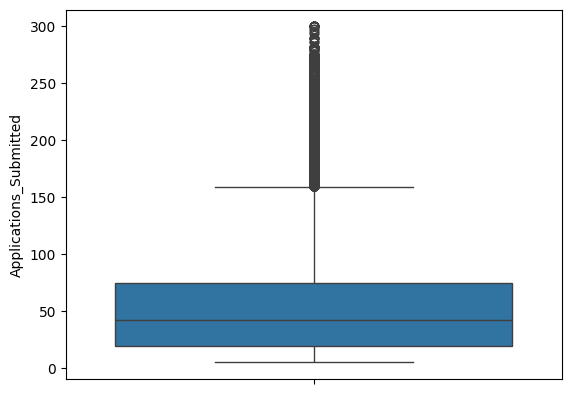

In [ ]:
import seaborn as sns
sns.boxplot(df['Applications_Submitted'])




# 📘 OUTLIER & ANALYSIS — FINAL RECAP NOTES

---

# 🔹 1. What is an Outlier?

👉 A value that is **significantly different from the majority of data**

---

# 🔹 2. How to Detect Outliers (IQR Method)

IQR = Q3 - Q1


Upper Bound = Q3 +  (1.5 x IQR)


Lower Bound = Q1 - (1.5 x IQR)


---

## 📌 In Your Case:

* Q1 = 19
* Q3 = 75
* IQR = 56

👉 Upper Bound:
   75+(1.5×56)=159

---

## 🎯 Final Rule:

👉
**Values > 159 = Outliers**

---

# 🔹 3. Important Concept

👉
**Outlier ≠ Wrong data**

---

## ✔ Outliers can be:

* Real behavior ✔
* Rare cases ✔
* Extreme effort ✔

---

## ❌ Don’t do:

* Remove blindly
* Assume unrealistic

---

# 🔹 4. When to Remove Outliers?

Remove ONLY if:

✔ Data entry error
✔ Impossible values
✔ Measurement mistake

---

# 🔹 5. When to KEEP Outliers?

Keep when:

✔ Real-world behavior
✔ Important for analysis
✔ Strategy differences

---

# 🔹 6. Key Insight from Your Dataset

👉
High applications (outliers)
            =

✔ More exposure

❌ Not guaranteed success

---

# 🔹 7. Core Analytical Thinking

👉
**Applications → Interviews → Offers**

This is a **pipeline**

---

# 🔹 8. GroupBy vs Correlation (Final Concept)

| Method      | Purpose                     |
| ----------- | --------------------------- |
| Correlation | Overall linear relationship |
| GroupBy     | Category-wise pattern       |

---

👉
**Correlation may hide patterns**
👉
**GroupBy reveals trends clearly**

---

# 🔹 9. Golden Rule (Very Important)

👉
**“First calculate → then conclude”**

---

# 🔹 10. Analyst Mindset Rules

✔ Say only what data proves
✔ Avoid assumptions
✔ Validate with numbers
✔ Separate:

* Data insight ✔
* Personal opinion ❌

---

# 🔹 11. Clean Insight Template

👉 Use this format:

**“As X increases, Y tends to [increase/decrease], but the relationship is [strong/weak], indicating that…”**

---

# 🔹 12. Your Final Understanding (Refined)

👉
**“Higher application counts increase interview opportunities, but success depends on progressing through later interview stages rather than application volume alone.”**





In [ ]:
df['is_outlier'] = df['Applications_Submitted'] > 159

df.groupby('is_outlier')['Offer_Received'].mean()

,Offer_Received
is_outlier,
False,0.343354
True,0.311777


In [ ]:
df['First_Round_Interviews'].describe()

,First_Round_Interviews
count,100000.00000
mean,2.16766
std,1.91176
min,0.00000
25%,1.00000
50%,2.00000
75%,3.00000
max,21.00000


First_Round_Interviews:
 Q1 = 1

 Q2 = 2

 Q3 = 3

 IQR = Q3 - Q1 = 2

 UPPER BOUND = Q3 + (1.5 x IQR)  
     => 3 + (1.5 x 2) = 6

 LOWER BOUND:

 =>   Q1 - (1.5 x IQR) = 1 -(3) = -2

####***VALUE LIE BELOW -2 OR ABOVE 6 OR IS OUTLIERS HERE IN FIRST_ROUND_INTERVIEW***






In [ ]:
df['Second_Round_Interviews'].describe()

,Second_Round_Interviews
count,100000.000000
mean,1.011640
std,1.138507
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,12.000000



Second_Round_Interviews:

 Q1 = 0

 Q2 = 1

 Q3 = 2

 IQR = Q3 - Q1 = 2



 UPPER BOUND = Q3 + (1.5 x IQR)  
     => 2 + (1.5 x 2) = 5

 LOWER BOUND:

 =>   Q1 - (1.5 x IQR) = 0 - (3) = -3

#####***VALUE LIE BELOW -3 OR ABOVE 5 OR IS OUTLIERS HERE IN SECOND_ROUND_INTERVIEW***






| First Round | Second Round | Result                  |
| ----------- | ------------ | ----------------------- |
| 7           | 6            | True ✔                  |
| 8           | 3            | False ❌ (second not >5) |
| 2           | 1            | False ❌                 |




>HERE,Active student who undergone many interview,that kind of student tend to get more offer i.e, **True**

>i.e,**False** means avergae or normal student who got less or avg. no of interviewsundergone tends to get lesser offer rate


| Group | Meaning                 | Offer Rate |
| ----- | ----------------------- | ---------- |
| False | Normal students         | 34%        |
| True  | High interview students | 81%        |



In [ ]:
df['high_interview'] = (df['First_Round_Interviews'] > 6) & (df['Second_Round_Interviews'] > 5)
df.groupby('high_interview')['Offer_Received'].mean()

,Offer_Received
high_interview,
False,0.340613
True,0.811798


In [ ]:
df["high"] = (df['Applications_Submitted'] > 159 ) & (df['First_Round_Interviews'] > 6) & (df['Second_Round_Interviews'] > 5)
df.groupby('high')['Offer_Received'].mean()

,Offer_Received
high,
False,0.341154
True,0.961749



##INSIGHT:
🚀While application volume increases exposure, only students who consistently convert applications into interview progressions achieve significantly higher offer rates. This trend remains consistent across all major categories, indicating that performance—not background—is the key driver of success.”

>🔥Students who consistently perform well across all stages (applications → interviews → advanced rounds) have a significantly higher probability of receiving offers.

👀You said:

“Normal students submit less applications”

👉 ❌ Don’t label without proof

Instead say:

✔
“Students not meeting high-performance criteria show lower success rates.”

> 🤨
  Students who progress through more interview stages across multiple companies have a significantly higher probability of receiving offers.

In [ ]:
#elite group: Top Performers
df["high1"] = (df['Applications_Submitted'] > 159 ) & (df['First_Round_Interviews'] > 6) & (df['Second_Round_Interviews'] > 5)
df.groupby(["high1",'Major_Category'])['Offer_Received'].mean()

high1  Major_Category
False  Arts              0.322736
       Business          0.354204
       Healthcare        0.327311
       Humanities        0.327890
       STEM              0.344187
True   Arts              1.000000
       Business          0.963636
       Healthcare        0.925926
       Humanities        0.892857
       STEM              1.000000
Name: Offer_Received, dtype: float64

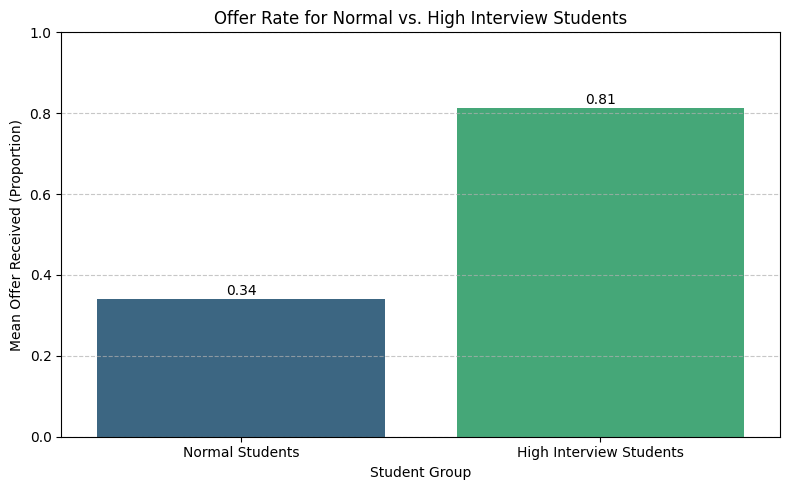

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean offer received for each 'high_interview' group
offer_rate_by_interview = df.groupby('high_interview')['Offer_Received'].mean().reset_index()

# Map boolean values to more descriptive labels for the plot
offer_rate_by_interview['high_interview_label'] = offer_rate_by_interview['high_interview'].map({False: 'Normal Students', True: 'High Interview Students'})

# Create the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='high_interview_label', y='Offer_Received', data=offer_rate_by_interview, hue='high_interview_label', palette='viridis', legend=False)
plt.title('Offer Rate for Normal vs. High Interview Students')
plt.xlabel('Student Group')
plt.ylabel('Mean Offer Received (Proportion)')
plt.ylim(0, 1) # Ensure y-axis is from 0 to 1 for proportions
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the bars
for index, row in offer_rate_by_interview.iterrows():
    plt.text(index, row['Offer_Received'] + 0.01, f'{row['Offer_Received']:.2f}', color='black', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
#Students who apply lot often because they are selected early, are struggling and keep them apply again and again.skill is matters
df.groupby(df['Applications_Submitted'] > 159)['Offer_Received'].mean()

,Offer_Received
Applications_Submitted,
False,0.343354
True,0.311777


>In case of second round interviews, someone reaches second rounds many times means, they are performing well and closer to final selection.thats why canditates reaches second round means, **86% percentage of offer received.**
           
           







#**⤵**

In [ ]:
df.groupby(df['Second_Round_Interviews'] > 5)['Offer_Received'].mean()

,Offer_Received
Second_Round_Interviews,
False,0.339778
True,0.860996


>🧠 Step-by-Step Explanation

🔵 Case 1: ≤ 6 interviews (34%)
    
    these student or canditate attends fewer interviews (attends first rounds) cracked earlier and  get offer.offere reciveing % increases.
✔ Meaning:

👉 They clear interviews more effectively



🔴 Case 2: > 6 interviews (24%)

    these categories of students attend more interviews and but fail to crack the interviews earlier.Offer Receiving is also lesser percntage.

✔ Meaning:
👉 They are failing repeatedly



In [ ]:
df.groupby(df['First_Round_Interviews'] > 6)['Offer_Received'].mean()

,Offer_Received
First_Round_Interviews,
False,0.345917
True,0.242208


🎯 Correct Insight (Clean Version)

👉
“The student is able to secure multiple interview opportunities but struggles to convert them into later stages, indicating a gap in interview performance or role alignment.”

🚀 Final One-Line Answer (Use This)

👉
The student has high interview exposure but low progression, indicating difficulty in converting opportunities into successful outcomes.

In [ ]:
t = (df['First_Round_Interviews'] > 6) & (df['Second_Round_Interviews'] > 5 )
df.groupby([t,'Offer_Salary'])['Offer_Received'].mean()

Offer_Salary
False  35000.0         1.0
       35021.0         1.0
       35123.0         1.0
       35468.0         1.0
       35474.0         1.0
                      ... 
True   104448.0        1.0
       107201.0        1.0
       107686.0        1.0
       109092.0        1.0
       118641.0        1.0
Name: Offer_Received, Length: 25688, dtype: float64